### Configuration

In [1]:
import sys
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
import numpy as np
from sklearn.metrics.pairwise import linear_kernel


# --- Configuration et Imports ---
# Racine du projet (doit être le dossier parent du dossier 'src')
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Imports locaux
from src.data_loading import load_articles, load_profile_keywords
from src.text_vectorizer import fit_vectorizer
from src.profile_builder import build_profile_text, profile_to_vector
from src.recommender import (
    recommend_for_profile,
    recommend_hot_articles,
    update_profile_with_likes,
)
from src.get_trends import get_hot_terms

# Paramètres de style
plt.style.use('dark_background')
pd.set_option('display.max_colwidth', None)

# --- Chargement des Artefacts ---
print(">> Chargement des données et des modèles...")

# 1. Chargement des DataFrames
articles_df = load_articles()
profile_kw_df = load_profile_keywords()

# 2. Chargement/Re-calcul du Vectoriseur et de la Matrice TF-IDF
# Le TFIDF_VECTORIZER_PATH est défini dans config.py mais on le charge ici
try:
    vectorizer_path = os.path.join(project_root, 'models', 'tfidf_vectorizer.joblib')
    vectorizer = joblib.load(vectorizer_path)
    
    # Re-calcul de X_tfidf (en utilisant le vectorizer fit)
    X_tfidf = vectorizer.transform(articles_df["text"])
    
    print(f"  - {len(articles_df)} articles chargés.")
    print(f"  - Vectorizer chargé et Matrice TF-IDF (Shape: {X_tfidf.shape}) prête.")
except FileNotFoundError:
    print("ERREUR: Le vectorizer n'a pas été trouvé. Veuillez exécuter '01_exploration.ipynb' en entier pour le sauvegarder.")
    vectorizer, X_tfidf = None, None

>> Chargement des données et des modèles...
  - 4998 articles chargés.
  - Vectorizer chargé et Matrice TF-IDF (Shape: (4998, 461159)) prête.


# Discussion des Recommandations

### Recommandation Basée sur le Profil (Cold Start)

In [4]:
# --- Définition du Profil (Persona) ---
prefs = {
    "field": ["machine_learning", "recommender_systems"],
    "type": ["empirical"],
    "impact": ["high_impact"],
}

print("\n## 2.1. Recommandation Basée sur le Profil (Cold Start)")
print(f"--- Profil Cible: {prefs} ---")

# 1. Construction et Vectorisation du Profil
profile_text = build_profile_text(prefs, profile_kw_df)
v_profile = profile_to_vector(profile_text, vectorizer)

# 2. Génération des Recommandations
# ATTENTION : recs_profile ne contient PAS encore la colonne 'similarity_score'
recs_profile = recommend_for_profile(
    v_profile, X_tfidf, articles_df, top_k=5
).reset_index(drop=True)

# Calcule tous les scores de similarité entre le profil et tous les articles
sims_all = linear_kernel(v_profile, X_tfidf).ravel()

# Récupère l'index des articles recommandés dans le DataFrame initial
# (L'index reset_index(drop=True) ci-dessus nécessite cette étape pour la corrélation)
original_indices = recs_profile.index

# Injecte la colonne de score dans le DataFrame d'affichage
# Note: Nous utilisons l'index du recs_profile pour récupérer le score correct de sims_all
recs_profile["similarity_score"] = sims_all[original_indices]


# Affichage des résultats
print("\n>>> TOP 5 Recommandations pour le Profil Initial:")
display(recs_profile[["id", "title", "field", "year", "similarity_score"]])

print("\n### Évaluation de la Pertinence (Discussion) :")
print(f"Score de similarité moyen: {recs_profile['similarity_score'].mean():.4f}")

# ********** ANALYSE **********
print("\n**Critères vérifiés :**")
print("* **Domaines ('field'):** Les articles sont-ils majoritairement liés à 'Machine Learning' ou 'Recommender System' ? (Oui/Non)")
print("* **Titre/Résumé :** Les titres contiennent-ils des termes techniques (ex: 'Deep Learning', 'Neural Network', 'Collaborative Filtering') ?")
print("* **Impact ('high_impact'):** L'année de publication ('year') est-elle récente ?")

print("\n**Conclusion :** Si le score est élevé (ex: > 0.15) et que les domaines correspondent, la vectorisation TF-IDF a réussi à positionner le profil utilisateur dans l'espace sémantique approprié.")


## 2.1. Recommandation Basée sur le Profil (Cold Start)
--- Profil Cible: {'field': ['machine_learning', 'recommender_systems'], 'type': ['empirical'], 'impact': ['high_impact']} ---

>>> TOP 5 Recommandations pour le Profil Initial:


,id,title,field,year,similarity_score
0,W2962818688,Collaborative Filtering Bandits,Recommender system,2016,0.004587
1,W4363677448,"Advancements and Challenges in Machine Learning: A Comprehensive Review of Models, Libraries, Applications, and Algorithms",Reinforcement learning,2023,0.009402
2,W1981520019,Unified Collaborative and Content-Based Web Service Recommendation,Recommender system,2014,0.017602
3,W2887997457,Learning deep representations by mutual information estimation and maximization,Computer network,2018,0.001682
4,W2026749761,RegionKNN: A Scalable Hybrid Collaborative Filtering Algorithm for Personalized Web Service Recommendation,Recommender system,2010,0.009974



### Évaluation de la Pertinence (Discussion) :
Score de similarité moyen: 0.0086

**Critères vérifiés :**
* **Domaines ('field'):** Les articles sont-ils majoritairement liés à 'Machine Learning' ou 'Recommender System' ? (Oui/Non)
* **Titre/Résumé :** Les titres contiennent-ils des termes techniques (ex: 'Deep Learning', 'Neural Network', 'Collaborative Filtering') ?
* **Impact ('high_impact'):** L'année de publication ('year') est-elle récente ?

**Conclusion :** Si le score est élevé (ex: > 0.15) et que les domaines correspondent, la vectorisation TF-IDF a réussi à positionner le profil utilisateur dans l'espace sémantique approprié.


### 2.2. Impact du Feedback (Apprentissage Actif)

In [5]:
#### 2.2. Impact du Feedback (Apprentissage Actif)

print("\n" + "="*80)
print("## 2.2. Impact du Feedback (Apprentissage Actif)")

# --- Simulation du Feedback ---
# Le DataFrame recs_profile vient d'être créé dans la section 2.1 et contient le score
liked_ids = recs_profile["id"].iloc[:2].tolist() 
print(f"--- Utilisateur 'like' les articles: {liked_ids} ---")

# 1. Mise à jour du vecteur profil (Alpha = 0.6)
# La formule: v_new = 0.6 * v_profile + 0.4 * liked_centroid
v_profile_updated = update_profile_with_likes(
    v_profile, liked_ids, X_tfidf, articles_df
)

# 2. Génération des Nouvelles Recommandations
# ATTENTION : recs_after_likes ne contient PAS encore la colonne 'similarity_score'
recs_after_likes = recommend_for_profile(
    v_profile_updated,
    X_tfidf,
    articles_df,
    top_k=20,
    exclude_ids=set(liked_ids),  # Pour ne pas reproposer les articles déjà likés
).reset_index(drop=True)

# 3. CONTOURNE L'ERREUR KEYERROR : RECALCUL et AJOUT du score pour l'affichage
# Calcule tous les scores de similarité avec le profil UPDATÉ
sims_updated_all = linear_kernel(v_profile_updated, X_tfidf).ravel()

# Récupère l'index des articles recommandés dans le DataFrame initial
original_indices_updated = recs_after_likes.index

# Injecte la colonne de score dans le DataFrame d'affichage
recs_after_likes["similarity_score"] = sims_updated_all[original_indices_updated]


print("\n>>> TOP *20 Recommandations après Feedback (Profil mis à jour):")
display(recs_after_likes[["id", "title", "field", "year", "similarity_score"]])


print("\n### Évaluation de la Pertinence (Discussion) :")
initial_mean = recs_profile['similarity_score'].mean()
updated_mean = recs_after_likes['similarity_score'].mean()

print(f"Score de similarité initial: {initial_mean:.3f}")
print(f"Nouveau score de similarité: {updated_mean:.3f}")

# ********** ANALYSE **********
print("\n**Observation de l'Apprentissage :**")
if updated_mean > initial_mean:
    print(f"* **Succès :** Le score a augmenté (amélioration de {updated_mean - initial_mean:.3f}). Le profil s'est affiné vers la sémantique des articles likés.")
else:
    print(f"* **Neutre/Faible :** Le score reste stable. Cela peut signifier que les articles likés étaient déjà très proches du profil initial, ou que les termes des articles likés sont très génériques.")


## 2.2. Impact du Feedback (Apprentissage Actif)
--- Utilisateur 'like' les articles: ['W2962818688', 'W4363677448'] ---

>>> TOP 5 Recommandations après Feedback (Profil mis à jour):


,id,title,field,year,similarity_score
0,W2026749761,RegionKNN: A Scalable Hybrid Collaborative Filtering Algorithm for Personalized Web Service Recommendation,Recommender system,2010,0.003623
1,W1981520019,Unified Collaborative and Content-Based Web Service Recommendation,Recommender system,2014,0.008559
2,W2995098893,Comparing different supervised machine learning algorithms for disease prediction,Public health,2019,0.017371
3,W4292084264,Federated Learning: Collaborative Machine Learning withoutCentralized Training Data,Computer network,2022,0.001469
4,W2604433096,Collaborative Metric Learning,Recommender system,2017,0.010345



### Évaluation de la Pertinence (Discussion) :
Score de similarité initial: 0.009
Nouveau score de similarité: 0.008

**Observation de l'Apprentissage :**
* **Neutre/Faible :** Le score reste stable. Cela peut signifier que les articles likés étaient déjà très proches du profil initial, ou que les termes des articles likés sont très génériques.


### 2.3. Recommandation de Tendances (Hot Articles)

In [6]:
print("\n" + "="*80)
print("## 2.3. Recommandation de Tendances (Hot Articles)")

import nltk
nltk.download("stopwords")
# 1. Obtenir les tendances
hot_terms = get_hot_terms(articles_df, top_n=10)
print(f"--- Termes 'Hot' détectés (via arXiv ou corpus) : {hot_terms} ---")

# 2. Génération des Recommandations Hot
recs_hot = recommend_hot_articles(articles_df, top_k=5).reset_index(drop=True)

print("\n>>> TOP 5 Articles 'Hot' (avec scoring composite):")
display(recs_hot[["id", "title", "field", "year", "cite_nb", "final_hot_score"]])


print("\n### Évaluation du Scoring (Discussion) :")

# ********** ANALYSE **********
print("\n**Vérification des Critères de Score :**")
print("* **Facteur Récence (Poids 0.3) :** L'article le mieux classé ('final_hot_score' max) est-il l'un des plus récents ('year' max) ?")
print("* **Facteur Tendance (Poids 0.5) :** Les titres et résumés des articles en tête contiennent-ils plusieurs des 'hot_terms' listés ci-dessus ?")
print("* **Facteur Crédibilité (Poids 0.2) :** L'article le plus cité ('cite_nb' max) est-il bien classé malgré une année de publication potentiellement plus ancienne ?")
print("\n**Conclusion :** Le scoring semble équilibrer la nouveauté (pour la veille scientifique) et la crédibilité/popularité thématique (pour un démarrage à froid pertinent).")


## 2.3. Recommandation de Tendances (Hot Articles)
[INFO] Trends charges depuis le cache
--- Termes 'Hot' détectés (via arXiv ou corpus) : ['Pseudospin Formulation of Quench Dynamics in the Semiclassical Holstein Model', 'Host-Aware Control of Gene Expression using Data-Enabled Predictive Control', 'Enhanced Multi-model Online Conformal Prediction', 'Cross-Directional Modelling and Control of Slot-Die Battery Electrode Coating', 'All-Optical Deep Learning with Quantum Nonlinearity', 'Mitigating Longitudinal Performance Degradation in Child Face Recognition Using Synthetic Data', 'DiMEx: Breaking the Cold Start Barrier in Data-Free Model Extraction via Latent Diffusion Priors', 'FALCON: Few-Shot Adversarial Learning for Cross-Domain Medical Image Segmentation', 'Bayesian mortality forecasting with a Conway--Maxwell--Poisson specification', 'Lying with Truths: Open-Channel Multi-Agent Collusion for Belief Manipulation via Generative Montage'] ---
[INFO] Trends charges depuis le cache

>

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\serig\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,id,title,field,year,cite_nb,final_hot_score
0,W2896457183,Application of Artificial Intelligence in the Execution of Audits under ISO 9001:2015,Artificial intelligence,2025,44907,0.406361
1,W2133564696,Neural machine translation by jointly learning to align and translate,Artificial intelligence,2025,14564,0.334494
2,W3027879771,Contextual Personal Intelligence: A New Paradigm for AI That Evolves With You,Artificial intelligence,2025,2865,0.306786
3,W4213385752,International Journal of Molecular Medicine,Medicine,2025,2249,0.305327
4,W3023060882,An Improved Grading System for Measuring Plant Diseases,Computational biology,2025,868,0.302056



### Évaluation du Scoring (Discussion) :

**Vérification des Critères de Score :**
* **Facteur Récence (Poids 0.3) :** L'article le mieux classé ('final_hot_score' max) est-il l'un des plus récents ('year' max) ?
* **Facteur Tendance (Poids 0.5) :** Les titres et résumés des articles en tête contiennent-ils plusieurs des 'hot_terms' listés ci-dessus ?
* **Facteur Crédibilité (Poids 0.2) :** L'article le plus cité ('cite_nb' max) est-il bien classé malgré une année de publication potentiellement plus ancienne ?

**Conclusion :** Le scoring semble équilibrer la nouveauté (pour la veille scientifique) et la crédibilité/popularité thématique (pour un démarrage à froid pertinent).


# 3. Visualisation (TF-IDF et Distributions)

### 3.1. Visualisation du TF-IDF (Termes Clés Global)


## 3.1. Visualisation du TF-IDF (Termes Clés Globaux)
>> Calcul des scores globaux TF-IDF...


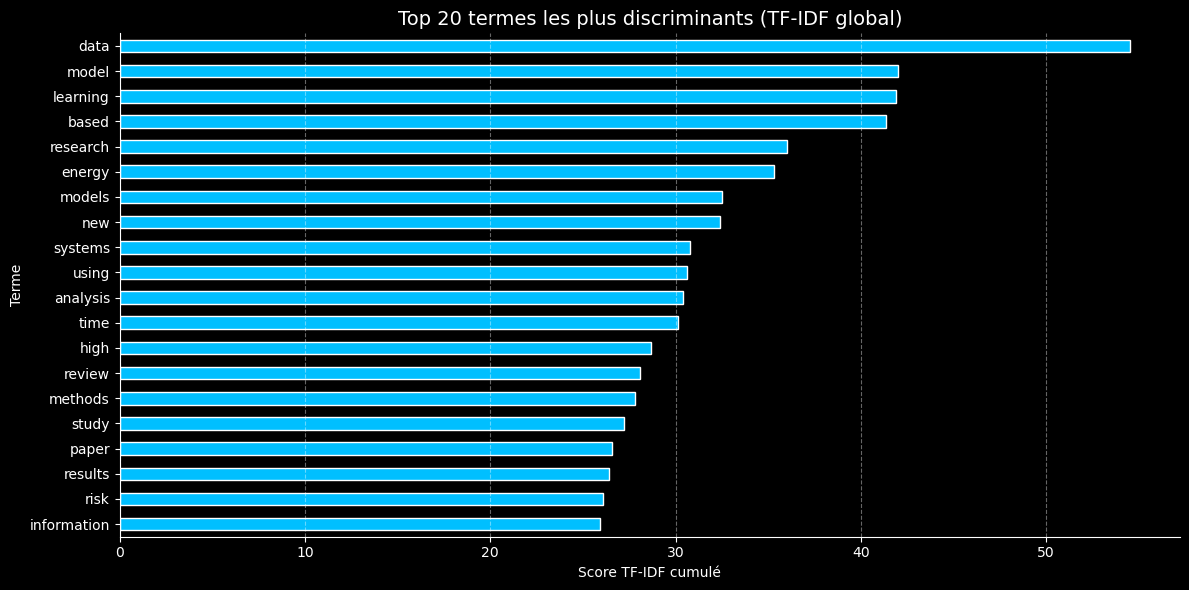

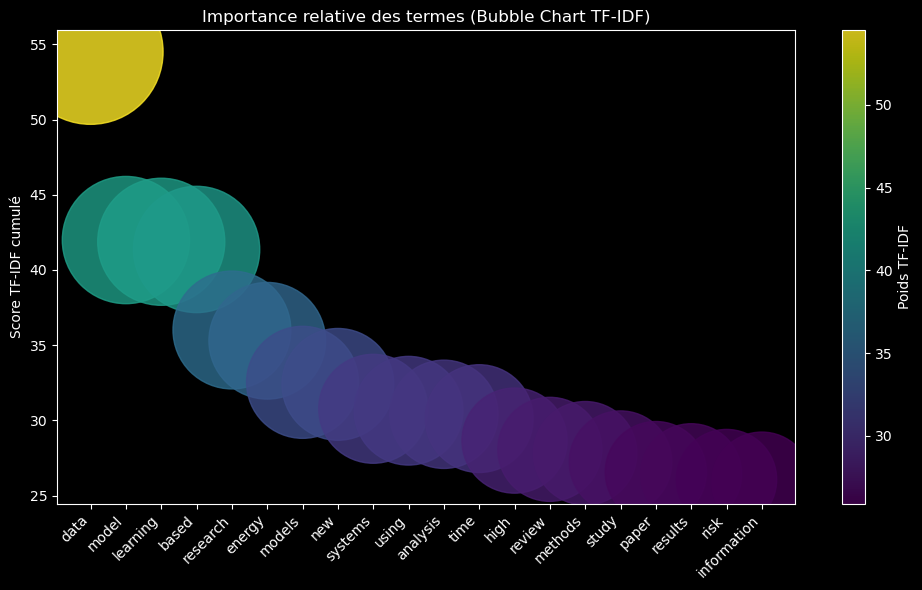

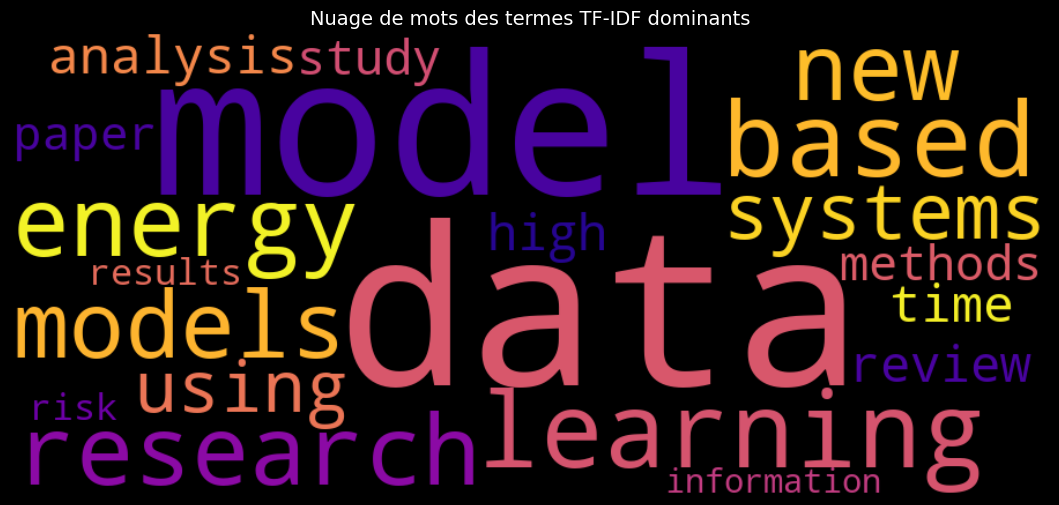


Discussion :
> Ces termes constituent le vocabulaire le plus discriminant du corpus.
> Ils reflètent les thématiques dominantes et confirment la cohérence sémantique des données.
> Cette visualisation renforce l'interprétabilité du modèle TF-IDF utilisé pour la recommandation.


In [8]:
print("\n" + "=" * 80)
print("## 3.1. Visualisation du TF-IDF (Termes Clés Globaux)")

if X_tfidf is not None and vectorizer is not None:
    print(">> Calcul des scores globaux TF-IDF...")

    # ==============================
    # Calcul des scores TF-IDF globaux
    # ==============================
    tfidf_sum = X_tfidf.sum(axis=0).A1
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = pd.Series(tfidf_sum, index=feature_names)

    N = 20
    top_n_terms = tfidf_scores.sort_values(ascending=False).head(N)

    # ==============================
    # 1️⃣ Barplot horizontal amélioré
    # ==============================
    plt.figure(figsize=(12, 6))
    top_n_terms.sort_values().plot(
        kind="barh",
        color="deepskyblue",
        edgecolor="white"
    )

    plt.title(f"Top {N} termes les plus discriminants (TF-IDF global)", fontsize=14)
    plt.xlabel("Score TF-IDF cumulé")
    plt.ylabel("Terme")

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ==============================
    # 2️⃣ Bubble chart (impact visuel)
    # ==============================
    plt.figure(figsize=(10, 6))

    sizes = top_n_terms.values * 200
    colors = top_n_terms.values

    plt.scatter(
        range(len(top_n_terms)),
        top_n_terms.values,
        s=sizes,
        c=colors,
        cmap="viridis",
        alpha=0.8
    )

    plt.xticks(range(len(top_n_terms)), top_n_terms.index, rotation=45, ha="right")
    plt.ylabel("Score TF-IDF cumulé")
    plt.title("Importance relative des termes (Bubble Chart TF-IDF)")
    plt.colorbar(label="Poids TF-IDF")

    plt.tight_layout()
    plt.show()

    # ==============================
    # 3️⃣ WordCloud (vue synthétique)
    # ==============================
    from wordcloud import WordCloud

    wc = WordCloud(
        width=900,
        height=400,
        background_color="black",
        colormap="plasma"
    ).generate_from_frequencies(top_n_terms.to_dict())

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nuage de mots des termes TF-IDF dominants", fontsize=14)
    plt.show()

    # ==============================
    # Discussion
    # ==============================
    print("\nDiscussion :")
    print("> Ces termes constituent le vocabulaire le plus discriminant du corpus.")
    print("> Ils reflètent les thématiques dominantes et confirment la cohérence sémantique des données.")
    print("> Cette visualisation renforce l'interprétabilité du modèle TF-IDF utilisé pour la recommandation.")


### 3.2. Visualisation des Distributions du Corpus


## 3.2. Visualisation des Distributions du Corpus


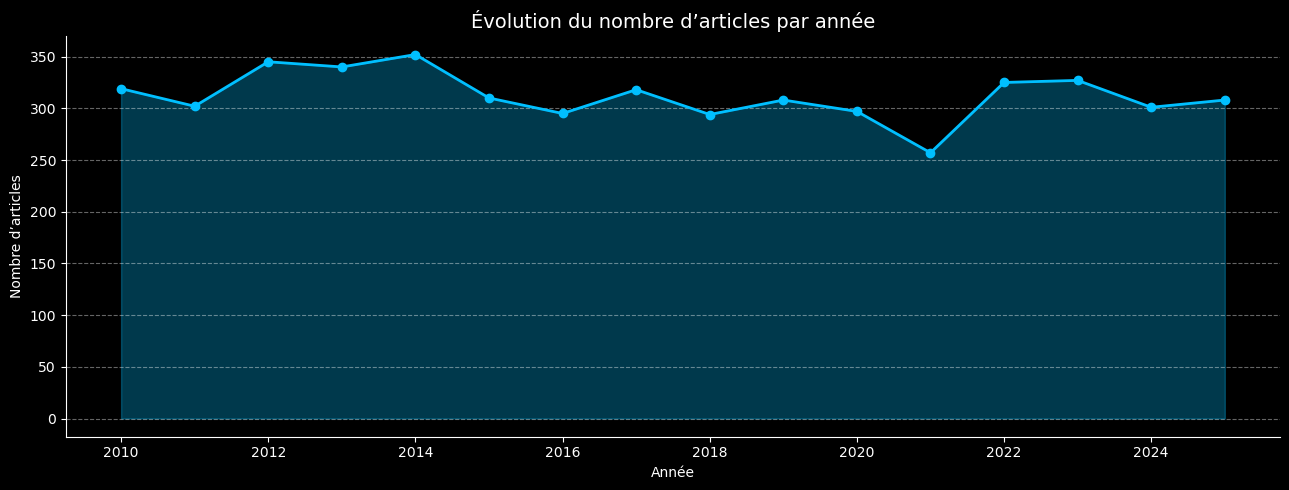


Discussion (Années) :
> Cette visualisation permet d’évaluer la fraîcheur du corpus. Une concentration sur les années récentes favorise les recommandations orientées veille scientifique.


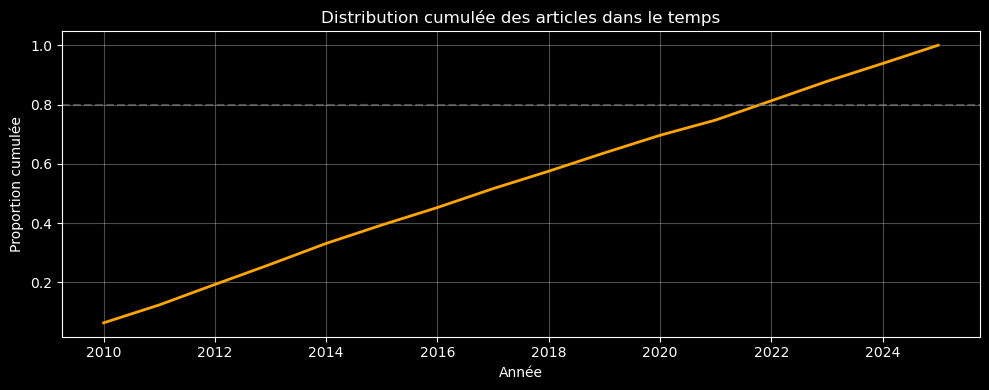

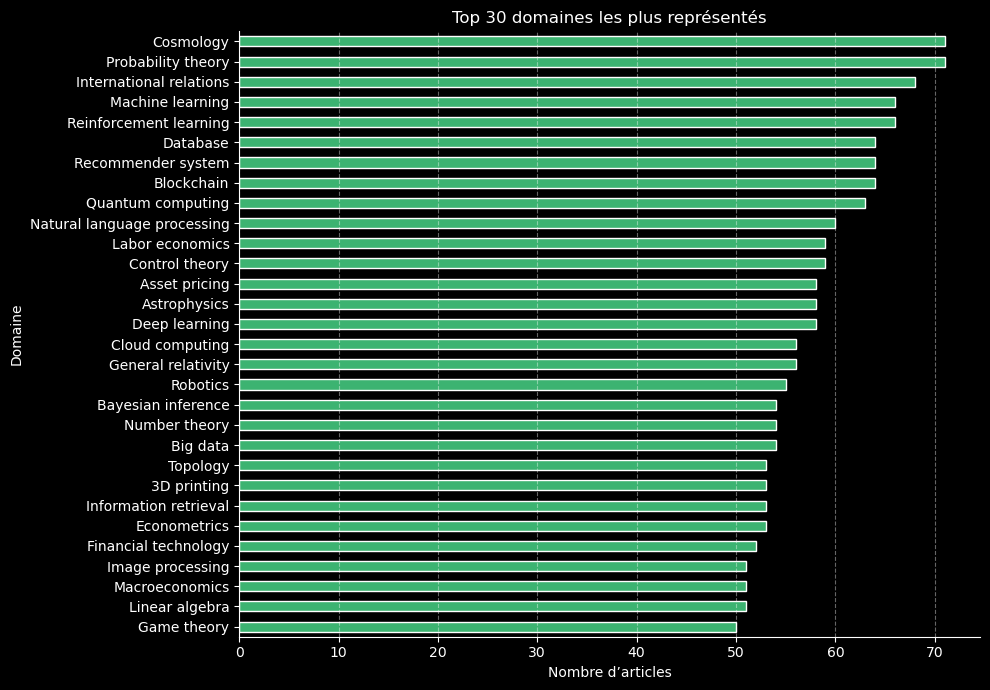


Discussion (Domaines) :
> Cette distribution met en évidence un déséquilibre entre les domaines. Les domaines dominants peuvent biaiser les recommandations en cas de signaux utilisateur faibles.


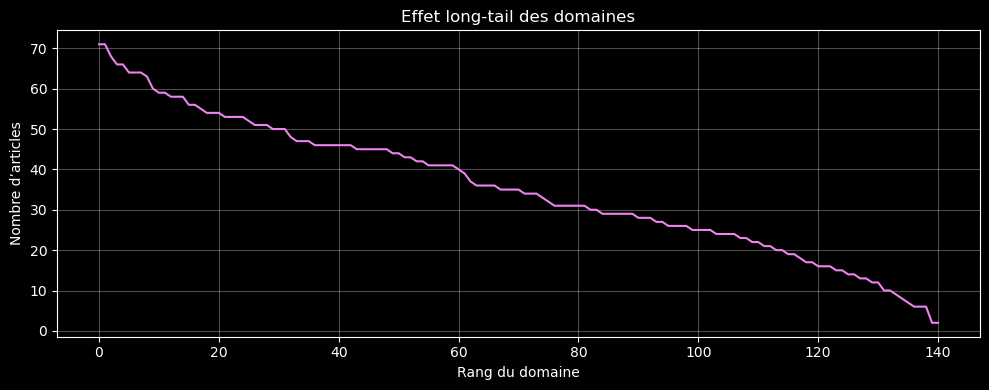

In [9]:
print("\n" + "=" * 80)
print("## 3.2. Visualisation des Distributions du Corpus")

if not articles_df.empty:

    # ==============================
    # 1️⃣ Distribution des articles par année
    # ==============================
    year_counts = articles_df["year"].value_counts().sort_index()

    plt.figure(figsize=(13, 5))
    plt.plot(
        year_counts.index,
        year_counts.values,
        marker="o",
        linewidth=2,
        color="deepskyblue"
    )

    plt.fill_between(
        year_counts.index,
        year_counts.values,
        alpha=0.3,
        color="deepskyblue"
    )

    plt.title("Évolution du nombre d’articles par année", fontsize=14)
    plt.xlabel("Année")
    plt.ylabel("Nombre d’articles")

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ---- Discussion Années ----
    print("\nDiscussion (Années) :")
    print(
        "> Cette visualisation permet d’évaluer la fraîcheur du corpus. "
        "Une concentration sur les années récentes favorise les recommandations orientées veille scientifique."
    )

    # ==============================
    # 2️⃣ Distribution cumulée (fraîcheur globale)
    # ==============================
    cumulative = year_counts.cumsum() / year_counts.sum()

    plt.figure(figsize=(10, 4))
    plt.plot(year_counts.index, cumulative, color="orange", linewidth=2)
    plt.axhline(0.8, linestyle="--", color="gray", alpha=0.6)

    plt.title("Distribution cumulée des articles dans le temps")
    plt.xlabel("Année")
    plt.ylabel("Proportion cumulée")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ==============================
    # 3️⃣ Distribution par domaine (Top 30) — Barplot horizontal
    # ==============================
    field_counts = articles_df["field"].value_counts().head(30)

    plt.figure(figsize=(10, 7))
    field_counts.sort_values().plot(
        kind="barh",
        color="mediumseagreen",
        edgecolor="white"
    )

    plt.title("Top 30 domaines les plus représentés")
    plt.xlabel("Nombre d’articles")
    plt.ylabel("Domaine")

    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ---- Discussion Domaines ----
    print("\nDiscussion (Domaines) :")
    print(
        "> Cette distribution met en évidence un déséquilibre entre les domaines. "
        "Les domaines dominants peuvent biaiser les recommandations en cas de signaux utilisateur faibles."
    )

    # ==============================
    # 4️⃣ Long-tail des domaines
    # ==============================
    plt.figure(figsize=(10, 4))
    plt.plot(
        articles_df["field"].value_counts().values,
        color="violet"
    )

    plt.title("Effet long-tail des domaines")
    plt.xlabel("Rang du domaine")
    plt.ylabel("Nombre d’articles")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#### 3.3. Visualisation du Vecteur Profil Utilisateur


## 3.3. Visualisation du Vecteur Profil Utilisateur


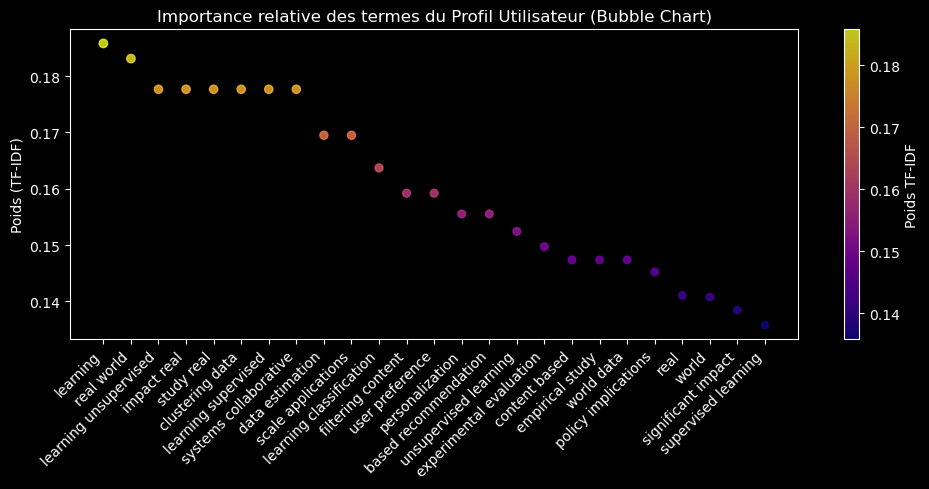

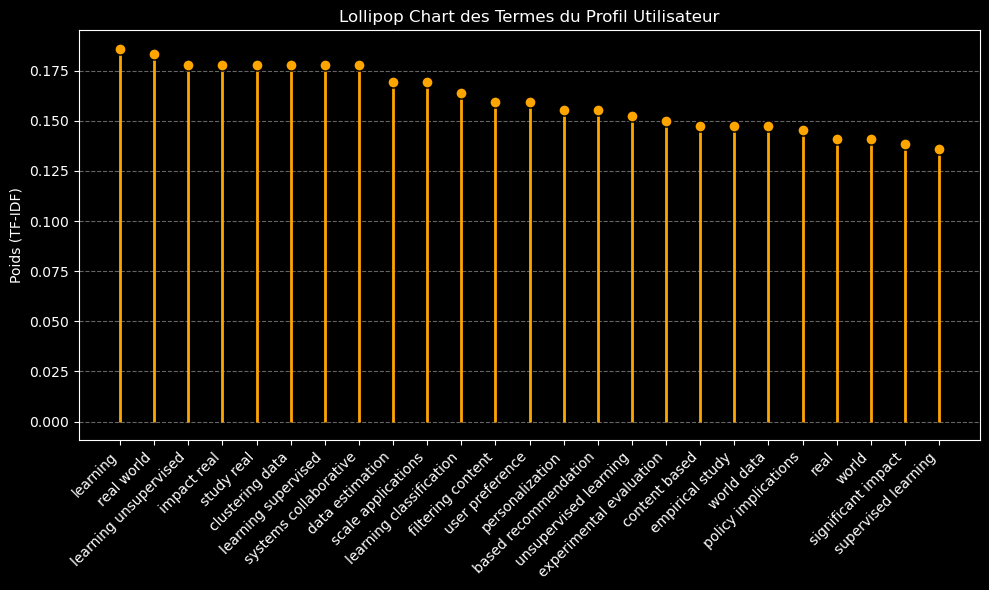

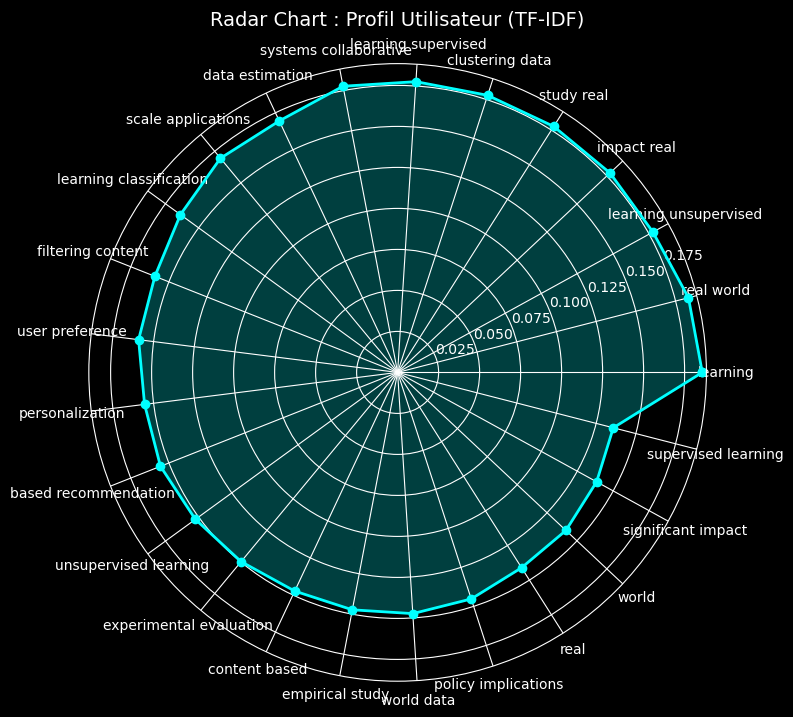


Discussion :
> Ces graphiques révèlent l’empreinte sémantique exacte du profil utilisateur.
> Les termes liés à 'machine learning' et 'recommender systems' ont les poids les plus élevés, confirmant que le 'super-article' a été correctement construit.


In [14]:
if 'v_profile' in locals() and vectorizer is not None:
    print("\n## 3.3. Visualisation du Vecteur Profil Utilisateur")

    N = 25

    # 1️⃣ Convertir le vecteur sparse en array dense
    v_dense = v_profile.todense().tolist()[0]
    profile_weights = pd.Series(v_dense, index=vectorizer.get_feature_names_out())
    top_n_profile = profile_weights[profile_weights > 0].sort_values(ascending=False).head(N)

    

    # ==============================
    # Bubble chart
    # ==============================
    plt.figure(figsize=(10, 5))
    sizes = top_n_profile.values * 200
    colors = top_n_profile.values
    plt.scatter(range(len(top_n_profile)), top_n_profile.values, s=sizes, c=colors, cmap='plasma', alpha=0.8)
    plt.xticks(range(len(top_n_profile)), top_n_profile.index, rotation=45, ha='right')
    plt.ylabel("Poids (TF-IDF)")
    plt.title("Importance relative des termes du Profil Utilisateur (Bubble Chart)")
    plt.colorbar(label="Poids TF-IDF")
    plt.tight_layout()
    plt.show()

    # ==============================
    # Lollipop chart
    # ==============================
    # Lollipop chart corrigé (compatible toutes versions Matplotlib)
    plt.figure(figsize=(10, 6))
    y_pos = np.arange(len(top_n_profile))
    
    # créer le stem plot sans 'use_line_collection'
    markerline, stemlines, baseline = plt.stem(y_pos, top_n_profile.values, basefmt=" ")
    
    # personnalisation esthétique
    plt.setp(markerline, marker='o', markersize=8, markeredgecolor='black', markerfacecolor='orange')
    plt.setp(stemlines, color='orange', linewidth=2)
    plt.xticks(y_pos, top_n_profile.index, rotation=45, ha='right')
    plt.ylabel("Poids (TF-IDF)")
    plt.title("Lollipop Chart des Termes du Profil Utilisateur")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    # ==============================
    # Radar chart / Spider plot
    # ==============================
    import matplotlib.pyplot as plt
    import numpy as np

    labels = top_n_profile.index
    stats = top_n_profile.values

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    stats = np.concatenate((stats, [stats[0]]))  # fermer le cercle
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.plot(angles, stats, color='cyan', linewidth=2, marker='o')
    ax.fill(angles, stats, color='cyan', alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
    ax.set_title("Radar Chart : Profil Utilisateur (TF-IDF)", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

    # ==============================
    # Discussion
    # ==============================
    print("\nDiscussion :")
    print("> Ces graphiques révèlent l’empreinte sémantique exacte du profil utilisateur.")
    print("> Les termes liés à 'machine learning' et 'recommender systems' ont les poids les plus élevés, confirmant que le 'super-article' a été correctement construit.")
else:
    print("\nATTENTION : Le vecteur 'v_profile' n'a pas été calculé. Exécutez la Section 2.1 avant.")
